# Pilot: verify use_mlm migration in plot_metric_distribution_by_experience

Runs the pilot end-to-end:
1. Load metrics_table the same way `260505_hierarchical_stats_function.ipynb` does.
2. Call `plot_metric_distribution_by_experience` with `use_mlm=False` -> writes `_tukey.csv`.
3. Call the same function with `use_mlm=True` (default) -> writes `_mlm.csv`.
4. Compare the two CSVs side by side. Show which `(cell_type, group1, group2)` tuples flipped significance.

The two saved CSVs live in the same `metric_distributions/` folder, distinguished only by suffix. Existing `_tukey.csv` files from prior runs are preserved (different filename).

In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context('notebook', font_scale=1.5, rc={'lines.markeredgewidth': 2})

In [25]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
import visual_behavior.data_access.utilities as utilities
from visual_behavior.data_access import loading as loading
import visual_behavior.visualization.utils as utils
import visual_behavior.visualization.ophys.platform_paper_figures as ppf
import visual_behavior.dimensionality_reduction.clustering.processing as processing

from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorOphysProjectCache

## Load data
Same loading recipe as the hierarchical stats notebook.

In [27]:
experience_levels = utils.get_new_experience_levels()
experience_level_colors = utils.get_experience_level_colors()
cell_types = utils.get_cell_types()

In [28]:
platform_cache_dir = loading.get_platform_analysis_cache_dir()
cache = loading._get_cache()
experiments_table = cache.get_ophys_experiment_table()
platform_experiments = loading.get_platform_paper_experiment_table(limit_to_closest_active=True)
print(len(platform_experiments.mouse_id.unique()), 'mice')
print(len(platform_experiments.index.unique()), 'experiments')

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

removing 1 problematic experiments
66 mice
402 experiments


In [29]:
data_type = 'filtered_events'
session_subset = 'full_session'
inclusion_criteria = 'platform_experiment_table'

metrics_table = processing.generate_merged_table_of_model_free_metrics(
    data_type=data_type, session_subset=session_subset,
    inclusion_criteria=inclusion_criteria, save_dir=loading.get_cell_metrics_dir()
)
metrics_table = metrics_table.merge(
    platform_experiments.reset_index(),
    on=['ophys_experiment_id', 'experience_level']
)
print(len(metrics_table.cell_specimen_id.unique()), 'cells')
print(len(metrics_table.mouse_id.unique()), 'mice')
print(len(metrics_table.ophys_experiment_id.unique()), 'experiments')

# sanity check: mouse_id must be present in metrics_table for the MLM path to work
assert 'mouse_id' in metrics_table.columns, 'mouse_id column is required for use_mlm=True'

filepath: /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_analysis_files/cell_metrics/merged_model_free_metrics_table_filtered_events_platform_experiment_table.csv
loading model free metrics table
14495 cells
66 mice
402 experiments


## Pilot: run with use_mlm=False then use_mlm=True
Both calls save to the same `metric_distributions/` folder. Different filenames so they coexist.

We use a small dedicated save dir so we don't clobber any prior runs.

In [30]:
# pilot save dir -- using a fresh subfolder so we have clean comparison files
pilot_save_dir = os.path.join(
    loading.get_platform_analysis_cache_dir(),
    'platform_paper_figures_final', 'PaperRevision_Neuron', 'mlm_pilot'
)
os.makedirs(os.path.join(pilot_save_dir, 'metric_distributions'), exist_ok=True)
print('Pilot save dir:', pilot_save_dir)

# pick one metric for the pilot
metric = 'mean_response_changes'
event_type = 'changes'

Pilot save dir: /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/platform_paper_figures_final/PaperRevision_Neuron/mlm_pilot


saving_stats


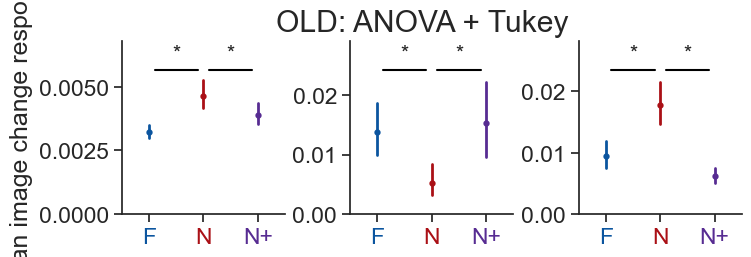

In [31]:
# --- Run with the OLD path (use_mlm=False) -> writes _tukey.csv ---
ax_old = ppf.plot_metric_distribution_by_experience(
    metrics_table, metric, event_type, data_type,
    plot_type='pointplot',
    ylabel='Mean image change response',
    save_dir=pilot_save_dir,
    suffix='_pilot',
    use_mlm=False,
)
plt.suptitle('OLD: ANOVA + Tukey', y=1.02)
plt.show()

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this messag

saving_stats


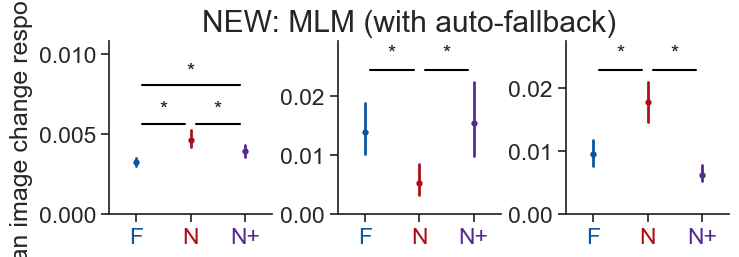

In [32]:
# --- Run with the NEW path (use_mlm=True, default) -> writes _mlm.csv ---
ax_new = ppf.plot_metric_distribution_by_experience(
    metrics_table, metric, event_type, data_type,
    plot_type='pointplot',
    ylabel='Mean image change response',
    save_dir=pilot_save_dir,
    suffix='_pilot',
    use_mlm=True,
)
plt.suptitle('NEW: MLM (with auto-fallback)', y=1.02)
plt.show()

## Compare the two saved CSVs
Both files are in `metric_distributions/`. We load them, line them up by `(cell_type, group1, group2)`, and report which tuples flipped significance.

In [33]:
import glob

# The plotting function mutates `suffix` by prepending '_experience_level_<plot_type>'
# when no hue is provided. Glob the directory to find the actual saved filenames
# rather than trying to reconstruct them exactly.
csv_dir = os.path.join(pilot_save_dir, 'metric_distributions')

stem = event_type + '_' + data_type + '_' + metric
tukey_matches = sorted(glob.glob(os.path.join(csv_dir, f'{stem}*_pilot_tukey.csv')))
mlm_matches = sorted(glob.glob(os.path.join(csv_dir, f'{stem}*_pilot_mlm.csv')))

print('Tukey CSV(s) found:', tukey_matches)
print('MLM CSV(s) found:  ', mlm_matches)
assert tukey_matches and mlm_matches, 'expected both _tukey.csv and _mlm.csv files in the pilot save dir'

tukey_path = tukey_matches[-1]
mlm_path = mlm_matches[-1]

tukey_df = pd.read_csv(tukey_path)
mlm_df = pd.read_csv(mlm_path)

print('\nOld CSV columns:', list(tukey_df.columns))
print('\nNew CSV columns:', list(mlm_df.columns))

Tukey CSV(s) found: ['/Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/platform_paper_figures_final/PaperRevision_Neuron/mlm_pilot/metric_distributions/changes_filtered_events_mean_response_changes_experience_level_pointplot_pilot_tukey.csv']
MLM CSV(s) found:   ['/Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/platform_paper_figures_final/PaperRevision_Neuron/mlm_pilot/metric_distributions/changes_filtered_events_mean_response_changes_experience_level_pointplot_pilot_mlm.csv']

Old CSV columns: ['Unnamed: 0', 'group1', 'group2', 'meandiff', 'p-adj', 'lower', 'upper', 'reject', 'x1', 'x2', 'column_to_compare', 'groups', 'one_way_anova_p_val', 'omnibus_pvalue', 'comparison', 'metric', 'cell_type']

New CSV columns: ['Unnamed: 0', 'metric', 'event_type', 'column_to_compare', 'groups', 'group1', 'group2', 'x1', 'x2', 'diff', 'pvalue_raw', 'pvalue_adj', 'pvalue', 'reject', 'model_type', 'omnibus_pvalue', 'icc'

In [34]:
# Inspect the new MLM table -- should have icc, mouse_variance, n_observations, mouse-level descriptives
new_display_cols = ['cell_type', 'group1', 'group2', 'diff', 'pvalue_adj', 'reject',
                    'model_type', 'omnibus_pvalue', 'icc',
                    'n_observations', 'n_groups', 'n_per_group',
                    'mean1_mouse', 'sem1_mouse', 'mean2_mouse', 'sem2_mouse']
new_display_cols = [c for c in new_display_cols if c in mlm_df.columns]
mlm_df[new_display_cols]

,cell_type,group1,group2,diff,pvalue_adj,reject,model_type,omnibus_pvalue,icc,n_observations,n_groups,n_per_group,mean1_mouse,sem1_mouse,mean2_mouse,sem2_mouse
0,Excitatory,Familiar,Novel,0.001414,1.389242e-05,True,mlm,2.529974e-05,0.017150,22680,34,667.1,0.002254,0.000359,0.002926,0.000530
1,Excitatory,Familiar,Novel +,0.000621,4.818131e-02,True,mlm,2.529974e-05,0.017150,22680,34,667.1,0.002254,0.000359,0.002652,0.000462
2,Excitatory,Novel,Novel +,0.000793,1.994718e-02,True,mlm,2.529974e-05,0.017150,22680,34,667.1,0.002926,0.000530,0.002652,0.000462
3,Sst Inhibitory,Familiar,Novel,-0.008758,1.535856e-02,True,mlm,4.223499e-03,0.042703,978,15,65.2,0.008326,0.002975,0.002786,0.000985
4,Sst Inhibitory,Familiar,Novel +,0.001152,7.297213e-01,False,mlm,4.223499e-03,0.042703,978,15,65.2,0.008326,0.002975,0.010027,0.005168
5,Sst Inhibitory,Novel,Novel +,-0.009910,7.931346e-03,True,mlm,4.223499e-03,0.042703,978,15,65.2,0.002786,0.000985,0.010027,0.005168
6,Vip Inhibitory,Familiar,Novel,0.008473,7.507605e-07,True,mlm,3.039032e-11,0.045360,2277,17,133.9,0.005395,0.002136,0.010184,0.002776
7,Vip Inhibitory,Familiar,Novel +,-0.002811,8.632314e-02,False,mlm,3.039032e-11,0.045360,2277,17,133.9,0.005395,0.002136,0.004095,0.001104
8,Vip Inhibitory,Novel,Novel +,0.011284,5.960233e-11,True,mlm,3.039032e-11,0.045360,2277,17,133.9,0.010184,0.002776,0.004095,0.001104


In [35]:
# Diff: which (cell_type, group1, group2) tuples flipped significance?
key_cols = ['cell_type', 'group1', 'group2']

old_keyed = tukey_df.set_index(key_cols)['reject'].rename('old_reject')
new_keyed = mlm_df.set_index(key_cols)['reject'].rename('new_reject')

diff = pd.concat([old_keyed, new_keyed], axis=1).reset_index()
diff['changed'] = diff['old_reject'] != diff['new_reject']

n_changed = int(diff['changed'].sum())
n_total = len(diff)
print(f'\n{n_changed} of {n_total} comparisons flipped significance')
print()
print(diff.to_string(index=False))


1 of 9 comparisons flipped significance

     cell_type   group1  group2  old_reject  new_reject  changed
    Excitatory Familiar   Novel        True        True    False
    Excitatory Familiar Novel +       False        True     True
    Excitatory    Novel Novel +        True        True    False
Sst Inhibitory Familiar   Novel        True        True    False
Sst Inhibitory Familiar Novel +       False       False    False
Sst Inhibitory    Novel Novel +        True        True    False
Vip Inhibitory Familiar   Novel        True        True    False
Vip Inhibitory Familiar Novel +       False       False    False
Vip Inhibitory    Novel Novel +        True        True    False


In [36]:
# Show only the flipped comparisons with the new-path p-values for context
flipped = diff[diff['changed']].merge(
    mlm_df[key_cols + ['pvalue_adj', 'icc', 'model_type', 'omnibus_pvalue']],
    on=key_cols, how='left'
)
print('Flipped comparisons with MLM context:')
print(flipped.to_string(index=False, float_format='{:.4e}'.format))

Flipped comparisons with MLM context:
 cell_type   group1  group2  old_reject  new_reject  changed  pvalue_adj        icc model_type  omnibus_pvalue
Excitatory Familiar Novel +       False        True     True  4.8181e-02 1.7150e-02        mlm      2.5300e-05


## What to look for

- **`model_type` column**: should be `mlm` for cell-level data (where multiple cells per mouse per condition exist). If you see `anova` here, the auto-fallback kicked in -- check why.
- **`icc` column**: between 0 and 1. A higher ICC means more between-mouse variance, justifying the random intercept.
- **`reject` column**: comparison of old vs new is the headline result. A small number of flips is expected; many flips would warrant revisiting paper text.
- **Both CSVs should coexist**: `_tukey.csv` and `_mlm.csv` in the same folder, distinguished only by suffix.